## Ember setup

In [10]:
%cd ../data/raw/.ember
!python setup.py install

[Errno 2] No such file or directory: '../data/raw/.ember'
/home/simone/UNI/Master/Tesi/thesis-project/data/raw/.ember
running install
/home/simone/miniconda3/envs/ember-extract/lib/python3.7/site-packages/setuptools/command/install.py:37: SetuptoolsDeprecationWarning: setup.py install is deprecated. Use build and pip and other standards-based tools.
  setuptools.SetuptoolsDeprecationWarning,
/home/simone/miniconda3/envs/ember-extract/lib/python3.7/site-packages/setuptools/command/easy_install.py:159: EasyInstallDeprecationWarning: easy_install command is deprecated. Use build and pip and other standards-based tools.
  EasyInstallDeprecationWarning,
running bdist_egg
running egg_info
writing ember.egg-info/PKG-INFO
writing dependency_links to ember.egg-info/dependency_links.txt
writing top-level names to ember.egg-info/top_level.txt
reading manifest file 'ember.egg-info/SOURCES.txt'
adding license file 'LICENSE.txt'
writing manifest file 'ember.egg-info/SOURCES.txt'
installing library c

## Library import

In [11]:
import ember
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

EMBER_PATH = "../ember2018"

## Load the dataset

In [12]:
X_train, y_train, X_test, y_test = ember.read_vectorized_features(EMBER_PATH)

# Filter only labeled samples from the dataset
mask = y_train != -1
X_labeled = X_train[mask]
y_labeled = y_train[mask]

print(f"Labeled samples: {X_labeled.shape[0]}")
print(f"Features per sample: {X_labeled.shape[1]}")
print(f"Benign: {(y_labeled == 0).sum()}")
print(f"Malware: {(y_labeled == 1).sum()}")
print(f"Unlabeled: {(y_train == -1).sum()}")

Labeled samples: 600000
Features per sample: 2381
Benign: 300000
Malware: 300000
Unlabeled: 200000


## Lable distribution

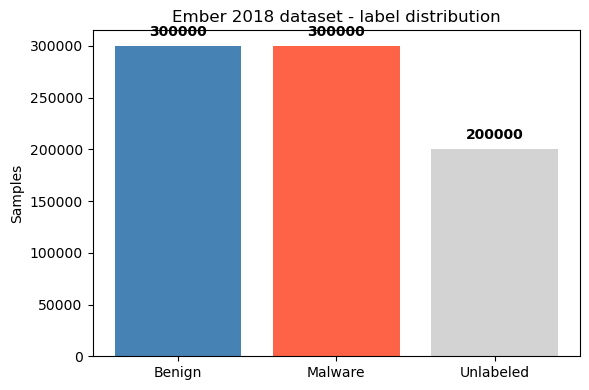

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Benign", "Malware", "Unlabeled"]

# Calculate counts using the original y_train for the unlabeled data
counts = [
    (y_labeled == 0).sum(), 
    (y_labeled == 1).sum(), 
    (y_train == -1).sum()
]

ax.bar(labels, counts, color=["steelblue", "tomato", "lightgray"])
ax.set_title("Ember 2018 dataset - label distribution")
ax.set_ylabel("Samples")

for i, v in enumerate(counts):
    ax.text(i, v + 10000, str(v), ha="center", fontweight="bold") # Increased offset slightly for larger numbers

plt.tight_layout()
plt.savefig("../../../experiments/label_distribution.png", dpi=150)
plt.show()

## Features statistics

In [ ]:
n_features = 2000
df = pd.DataFrame(X_labled[:n_features])
print(f"Statistics on {n_features} features:\n")
print(df.describe().round(3))

Statistics on 2000 features:

           0         1         2         3         4         5         6     \
count  2000.000  2000.000  2000.000  2000.000  2000.000  2000.000  2000.000   
mean      0.309     0.012     0.006     0.006     0.011     0.004     0.003   
std       0.194     0.009     0.013     0.014     0.027     0.012     0.007   
min       0.004     0.000     0.000     0.000     0.000     0.000     0.000   
25%       0.171     0.007     0.004     0.003     0.004     0.002     0.002   
50%       0.264     0.010     0.005     0.004     0.007     0.003     0.003   
75%       0.459     0.014     0.007     0.006     0.010     0.004     0.004   
max       0.925     0.097     0.425     0.229     0.387     0.266     0.234   

           7         8         9     ...      2371         2372      2373  \
count  2000.000  2000.000  2000.000  ...  2000.000     2000.000  2000.000   
mean      0.003     0.007     0.002  ...    13.324    47669.156    14.570   
std       0.003     0.005  

## Features distribution per class

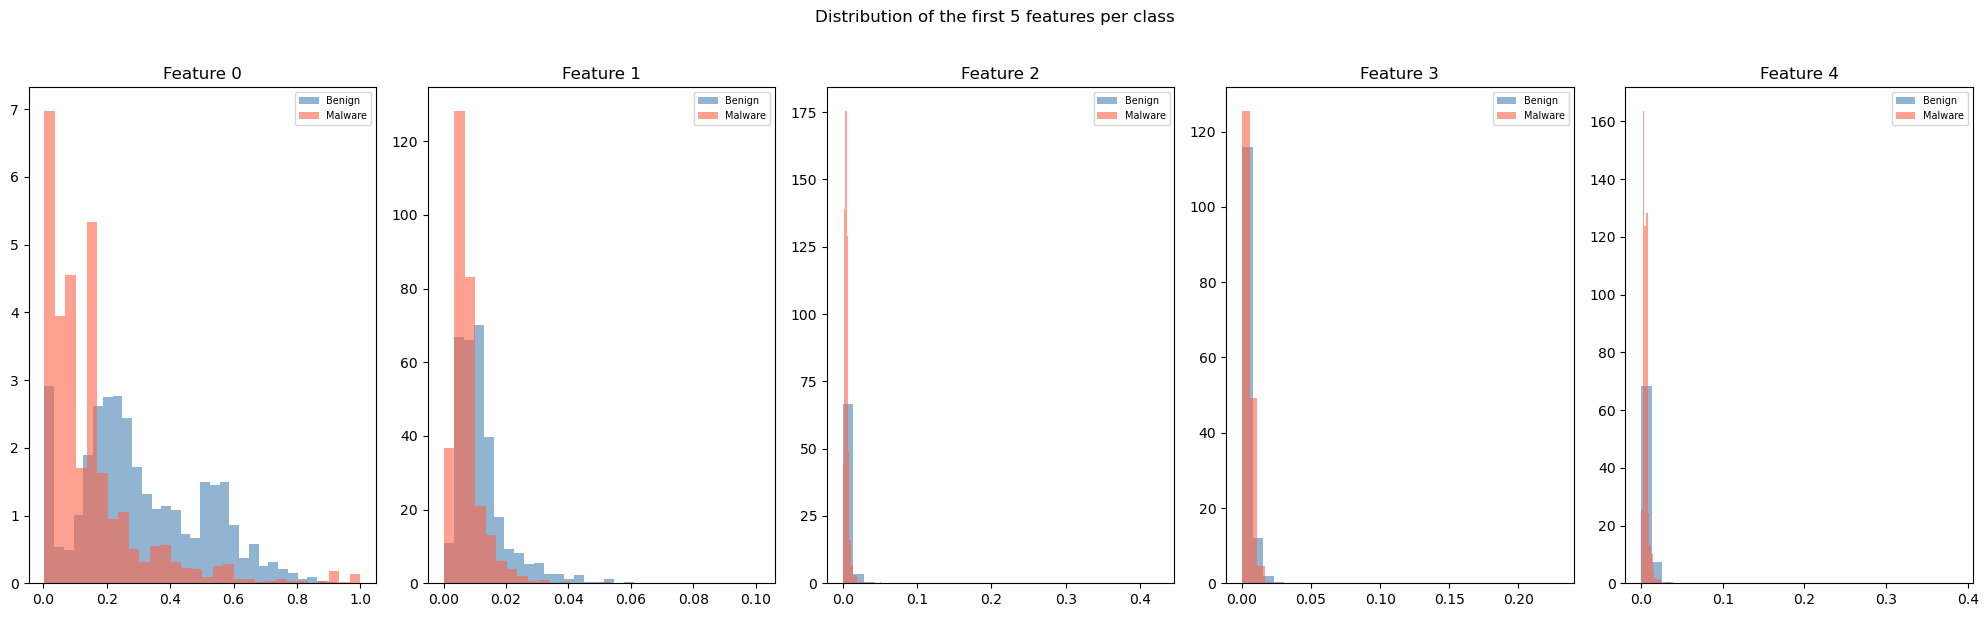

In [ ]:
# compare between the first 10 features fo benign and malware
n_features = 5
fig, axes = plt.subplots(1, n_features, figsize=(4 * n_features, 6))
if n_features == 1:
    axes = [axes]  # wrap it so the loop still works
axes.flatten()

X_ben = X_labled[y_labled == 0][:2000]
X_mal = X_labled[y_labled == 1][:2000]

for i, ax in enumerate(axes):
    ax.hist(X_ben[:, i], bins=30, alpha=0.6,
            color="steelblue", label="Benign", density=True)
    ax.hist(X_mal[:, i], bins=30, alpha=0.6,
            color="tomato", label="Malware", density=True)
    ax.set_title(f"Feature {i}")
    ax.legend(fontsize=7)

plt.suptitle(f"Distribution of the first {n_features} features per class", y=1.02)
plt.tight_layout()
plt.savefig("../experiments/feature_distributions.png", dpi=150)
plt.show()